#Cell 1 — Setup + Mount Drive + Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Cell 2 — Load Dataset (CSV)

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Advanced Machine Learning/classexampleOpenAI - classexampleOpenAI.csv"

df = pd.read_csv(DATA_PATH, skiprows=1)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (89, 9)
Columns: ['Name', 'Grade', 'Course', 'Date', 'Teacher', 'Text', 'results', 'grade', 'summary']


,Name,Grade,Course,Date,Teacher,Text,results,grade,summary
0,wood-leness,senior,Digital Narrative,10/11/2023,Dr. Margini,the extremely limited gameplay of citizen slee...,1. Writing Quality: 3 - There are some grammat...,1. Writing Quality: 3 - There are some grammat...,2. Idea Quality: 4 - The idea of focusing on c...
1,wood-leness,senior,Digital Narrative,10/23/2023,Dr. Margini,citizen sleeper utilizes highly detailed chara...,Writing Quality: 3 - There are a few punctuati...,Writing Quality: 3 - There are a few punctuati...,Idea Quality: 4 - The idea of using character ...
2,bianchi,senior,Science Fiction and Social Change,12/18/2023,Ms. Morgan,\nwhat does it mean to be human does it mean g...,1. Writing Quality: 4 - The writing is general...,1. Writing Quality: 4 - The writing is general...,2. Idea Quality: 5 - The ideas are original an...
3,bianchi,senior,Science Fiction and Social Change,19-Oct-23,Ms. Morgan,the infinite quest for freedom the irrational ...,1. Writing Quality: 2\n2. Idea Quality: 3\n3. ...,1. Writing Quality: 2,2. Idea Quality: 3\n3. Coherence and Structure...
4,bianchi,senior,NaN,NaN,NaN,catalua y coln la perdida de idioma y autonomi...,Writing Quality: 3\nIdea Quality: 4\nCoherence...,Writing Quality: 3,Idea Quality: 4\nCoherence and Structure: 3\nO...


#Cell 3 — EDA (Counts, Missing, Length stats, Class balance)

Name        0
Grade       0
Course     11
Date       25
Teacher    16
Text        0
results     0
grade       0
summary     1
dtype: int64

Character length stats:
 count       71.000000
mean      7538.887324
std       4533.727780
min       1749.000000
25%       4790.500000
50%       5955.000000
75%       8846.000000
max      27452.000000
Name: char_len, dtype: float64

Word length stats:
 count      71.000000
mean     1233.464789
std       672.971276
min       305.000000
25%       825.000000
50%      1037.000000
75%      1463.000000
max      3991.000000
Name: word_len, dtype: float64

Teacher distribution:
 Teacher
Dr. Chuang                   11
Dr. Margini                   9
Ms. Anderson                  7
Dr. Bufkin                    6
Ms. Morgan                    5
Mr. McCrink                   4
Dr. Morse                     3
Dr. Rhyner                    3
Dr. Ermer                     3
Ms. Cornick                   3
Dr. Brown                     2
Mrs. Carson             

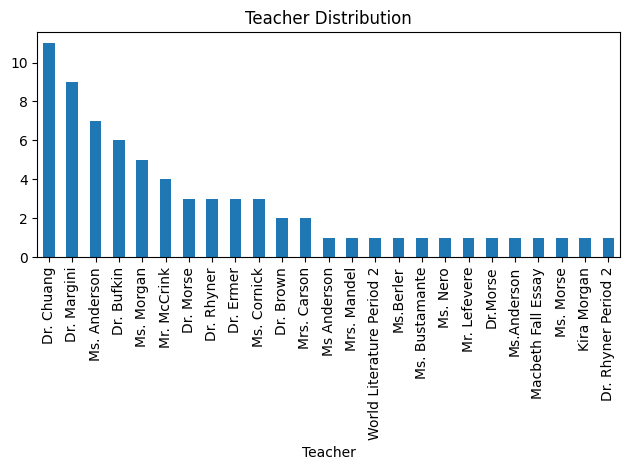

/tmp/ipython-input-2562316150.py:30: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2562316150.py:30: UserWarning: Glyph 153 (\x99) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2562316150.py:30: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2562316150.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 153 (\x99) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyp

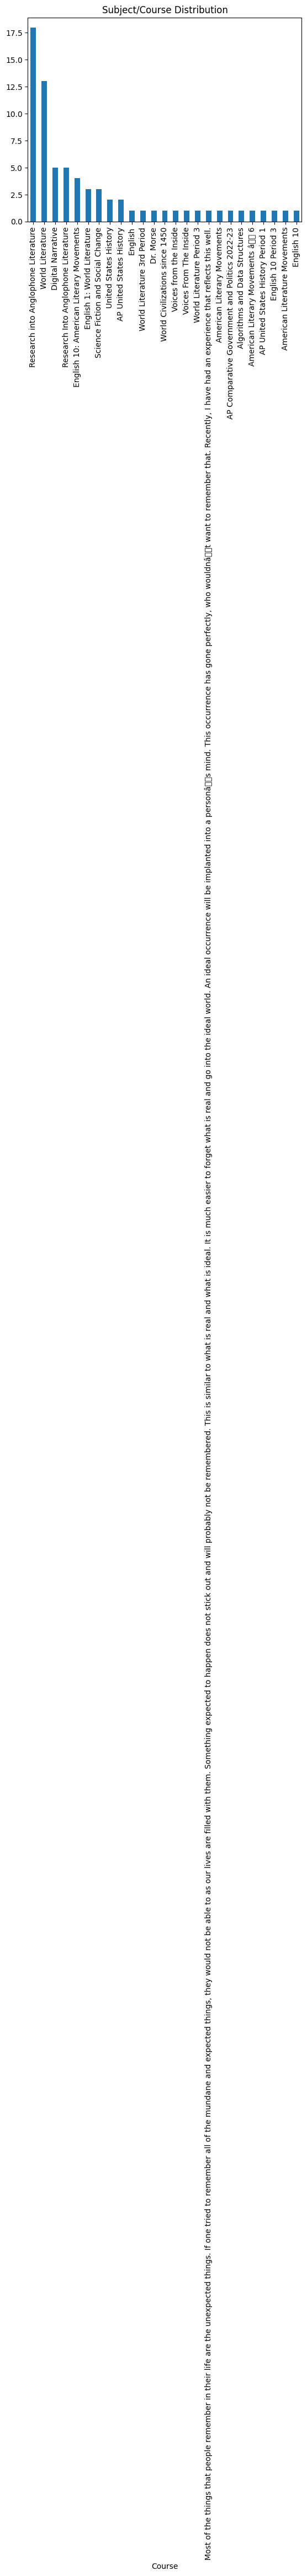


Majority baseline Teacher: 0.15492957746478872
Majority baseline Subject: 0.2535211267605634


In [ ]:
TEXT_COL = "Text"
TEACHER_COL = "Teacher"
SUBJECT_COL = "Course"   # course = subject

print(df.isna().sum())

df = df.dropna(subset=[TEXT_COL, TEACHER_COL, SUBJECT_COL]).copy()

df["char_len"] = df[TEXT_COL].astype(str).apply(len)
df["word_len"] = df[TEXT_COL].astype(str).apply(lambda x: len(str(x).split()))

print("\nCharacter length stats:\n", df["char_len"].describe())
print("\nWord length stats:\n", df["word_len"].describe())

teacher_counts = df[TEACHER_COL].value_counts()
subject_counts = df[SUBJECT_COL].value_counts()

print("\nTeacher distribution:\n", teacher_counts)
print("\nSubject/Course distribution:\n", subject_counts)

plt.figure()
teacher_counts.plot(kind="bar")
plt.title("Teacher Distribution")
plt.tight_layout()
plt.show()

plt.figure()
subject_counts.plot(kind="bar")
plt.title("Subject/Course Distribution")
plt.tight_layout()
plt.show()

print("\nMajority baseline Teacher:", teacher_counts.max()/teacher_counts.sum())
print("Majority baseline Subject:", subject_counts.max()/subject_counts.sum())

#Tutorial Section

In [ ]:
import nltk

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger")
nltk.download("maxent_ne_chunker")
nltk.download("words")
nltk.download("tagsets")
nltk.download("punkt_tab") # Added to resolve the LookupError for punkt_tab

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Package tagset

True

In [ ]:
sample_text = df[TEXT_COL].iloc[0]
print(sample_text[:800])

the extremely limited gameplay of citizen sleeper results in the entire focus of the player being on the story they create for themselves much of the focus of the game is dialogue that the player can choose responses to in order to create their own story for example the start of the game is narrated by your character explaining the backstory of your current situation even when the game finally allows significant player input it is almost as simple as a point and click the lack of skill based gameplay reduces the number of aspects the game has that a player can focus on it could be argued that this detracts from the overall experience but i believe that highly technical gameplay is not necessary for a game like citizen sleeper in fact not having to learn mechanics allows for a more personal


In [ ]:
from nltk.tokenize import sent_tokenize, word_tokenize

sentences = sent_tokenize(sample_text)
words = word_tokenize(sample_text)

print(f"{len(sentences)} sentences")
print(f"{len(words)} tokens")

sentences[:5]

1 sentences
305 tokens


['the extremely limited gameplay of citizen sleeper results in the entire focus of the player being on the story they create for themselves much of the focus of the game is dialogue that the player can choose responses to in order to create their own story for example the start of the game is narrated by your character explaining the backstory of your current situation even when the game finally allows significant player input it is almost as simple as a point and click the lack of skill based gameplay reduces the number of aspects the game has that a player can focus on it could be argued that this detracts from the overall experience but i believe that highly technical gameplay is not necessary for a game like citizen sleeper in fact not having to learn mechanics allows for a more personal experience with the story the whole experience relates to the story because there is not time spent on specific inputs or levels \n \nthe rng based gameplay creates tense situations for the player 

In [ ]:
from nltk.probability import FreqDist

fdist = FreqDist(words)
fdist.most_common(15)

[('the', 30),
 ('of', 14),
 ('a', 11),
 ('player', 10),
 ('that', 10),
 ('is', 8),
 ('game', 7),
 ('to', 7),
 ('for', 6),
 ('experience', 5),
 ('gameplay', 4),
 ('in', 4),
 ('on', 4),
 ('story', 4),
 ('creates', 4)]

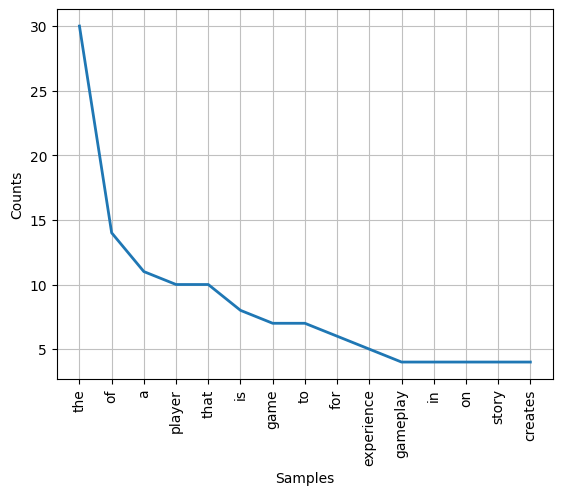

In [ ]:
fdist.plot(15)
plt.show()

In [ ]:
words_no_punc = []
for w in words:
    if w.isalpha():
        words_no_punc.append(w.lower())

print(words_no_punc[:50])
print("Clean token count:", len(words_no_punc))

fdist2 = FreqDist(words_no_punc)
fdist2.most_common(15)

['the', 'extremely', 'limited', 'gameplay', 'of', 'citizen', 'sleeper', 'results', 'in', 'the', 'entire', 'focus', 'of', 'the', 'player', 'being', 'on', 'the', 'story', 'they', 'create', 'for', 'themselves', 'much', 'of', 'the', 'focus', 'of', 'the', 'game', 'is', 'dialogue', 'that', 'the', 'player', 'can', 'choose', 'responses', 'to', 'in', 'order', 'to', 'create', 'their', 'own', 'story', 'for', 'example', 'the', 'start']
Clean token count: 305


[('the', 30),
 ('of', 14),
 ('a', 11),
 ('player', 10),
 ('that', 10),
 ('is', 8),
 ('game', 7),
 ('to', 7),
 ('for', 6),
 ('experience', 5),
 ('gameplay', 4),
 ('in', 4),
 ('on', 4),
 ('story', 4),
 ('creates', 4)]

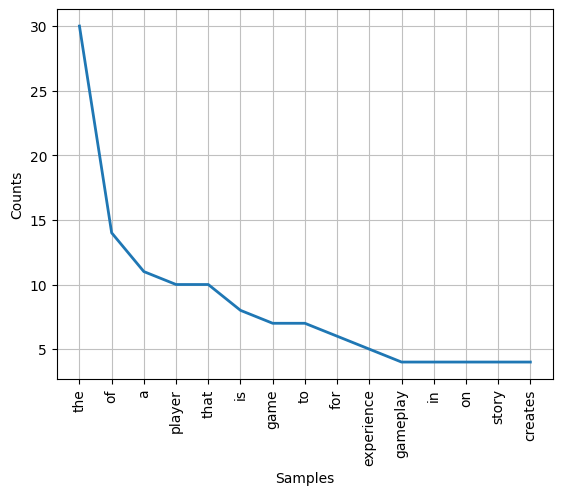

In [ ]:
fdist2.plot(15)
plt.show()

In [ ]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

clean_words = []
for w in words_no_punc:
    if w not in stop_words:
        clean_words.append(w)

print(clean_words[:50])
print("After stopword removal:", len(clean_words))

fdist3 = FreqDist(clean_words)
fdist3.most_common(15)


['extremely', 'limited', 'gameplay', 'citizen', 'sleeper', 'results', 'entire', 'focus', 'player', 'story', 'create', 'much', 'focus', 'game', 'dialogue', 'player', 'choose', 'responses', 'order', 'create', 'story', 'example', 'start', 'game', 'narrated', 'character', 'explaining', 'backstory', 'current', 'situation', 'even', 'game', 'finally', 'allows', 'significant', 'player', 'input', 'almost', 'simple', 'point', 'click', 'lack', 'skill', 'based', 'gameplay', 'reduces', 'number', 'aspects', 'game', 'player']
After stopword removal: 154


[('player', 10),
 ('game', 7),
 ('experience', 5),
 ('gameplay', 4),
 ('story', 4),
 ('creates', 4),
 ('control', 4),
 ('results', 3),
 ('focus', 3),
 ('citizen', 2),
 ('sleeper', 2),
 ('create', 2),
 ('character', 2),
 ('allows', 2),
 ('lack', 2)]

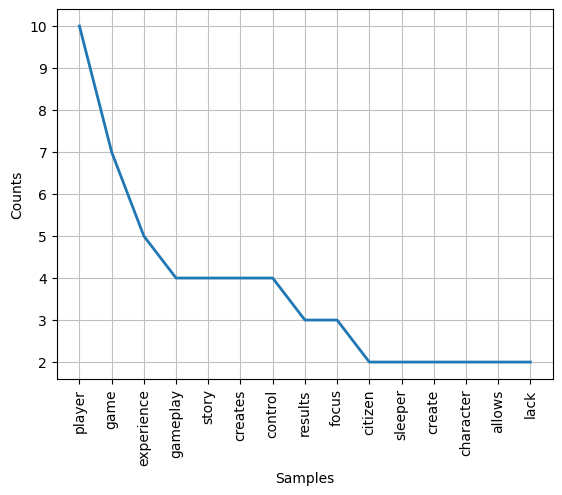

In [ ]:
fdist3.plot(15)
plt.show()


In [ ]:
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

porter = PorterStemmer()
lemmatizer = WordNetLemmatizer()

test_words = ["study","studying","studies","studied","plays","leaves","decreases"]

print("STEMMING:")
for w in test_words:
    print(w, "->", porter.stem(w))

print("\nLEMMATIZATION:")
for w in test_words:
    print(w, "->", lemmatizer.lemmatize(w))


STEMMING:
study -> studi
studying -> studi
studies -> studi
studied -> studi
plays -> play
leaves -> leav
decreases -> decreas

LEMMATIZATION:
study -> study
studying -> studying
studies -> study
studied -> studied
plays -> play
leaves -> leaf
decreases -> decrease


#Classification

#Preprocessing Function

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def preprocess_for_ml(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Text_clean"] = df[TEXT_COL].apply(preprocess_for_ml)
df[["Text", "Text_clean"]].head()


,Text,Text_clean
0,the extremely limited gameplay of citizen slee...,the extremely limited gameplay of citizen slee...
1,citizen sleeper utilizes highly detailed chara...,citizen sleeper utilizes highly detailed chara...
2,\nwhat does it mean to be human does it mean g...,what does it mean to be human does it mean go ...
3,the infinite quest for freedom the irrational ...,the infinite quest for freedom the irrational ...
5,lowkey i do think skyler is annoying though \n...,lowkey i do think skyler is annoying though sk...


#Train/Val/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

def split_data(X, y, test_size=0.2, val_size=0.2, random_state=42):
    X_train_temp, X_test, y_train_temp, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    val_prop = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_temp, y_train_temp, test_size=val_prop, stratify=y_train_temp, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


#Vectorizers (CountVectorizer + TFIDF) with ngrams

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

vectorizer_choices = {
    "BOW_uni": CountVectorizer(ngram_range=(1,1), max_features=5000),
    "BOW_bi":  CountVectorizer(ngram_range=(1,2), max_features=5000),
    "TFIDF_uni": TfidfVectorizer(ngram_range=(1,1), max_features=5000),
    "TFIDF_bi":  TfidfVectorizer(ngram_range=(1,2), max_features=5000),
}


#Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RF": RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced_subsample")
}


#Train + Compare Function

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def run_experiments(X_train, y_train, X_val, y_val):
    results = []
    best = None
    best_score = -1

    for vec_name, vec in vectorizer_choices.items():
        Xtr = vec.fit_transform(X_train)
        Xva = vec.transform(X_val)

        for model_name, model in models.items():
            model.fit(Xtr, y_train)
            preds = model.predict(Xva)

            acc = accuracy_score(y_val, preds)
            f1w = f1_score(y_val, preds, average="weighted")
            f1m = f1_score(y_val, preds, average="macro")

            results.append([vec_name, model_name, acc, f1w, f1m])

            if f1w > best_score:
                best_score = f1w
                best = (vec_name, vec, model_name, model)

    results_df = pd.DataFrame(results, columns=["Vectorizer","Model","Val_Acc","Val_F1_weighted","Val_F1_macro"])
    results_df = results_df.sort_values("Val_F1_weighted", ascending=False)
    return results_df, best


In [ ]:
def group_rare_classes(df, label_col, min_count=3, other_name="Other"):
    """
    Groups labels that appear fewer than min_count times into a single 'Other' category.
    This helps stratified splitting work properly on small datasets.
    """
    value_counts = df[label_col].value_counts()

    rare_labels = value_counts[value_counts < min_count].index

    df = df.copy()
    df[label_col] = df[label_col].apply(
        lambda x: other_name if x in rare_labels else x
    )

    return df


#Teacher Prediction

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

X_original = df["Text_clean"].values
y_teacher_original = df[TEACHER_COL].values

# Create a temporary DataFrame for grouping rare classes
df_temp = pd.DataFrame({
    "Text_clean": X_original,
    TEACHER_COL: y_teacher_original
})

# Group rare teacher classes with a min_count of 3 for robust stratified splitting
df_grouped = group_rare_classes(df_temp, TEACHER_COL, min_count=3, other_name="OtherTeacher")

X = df_grouped["Text_clean"].values
y = df_grouped[TEACHER_COL].values

# Now perform the stratified train/val/test split with the grouped labels
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

# Majority baseline
majority = pd.Series(y_test).value_counts().idxmax()
baseline_acc = (y_test == majority).mean()
print("Teacher baseline accuracy:", baseline_acc)

results_teacher, best_teacher = run_experiments(X_train, y_train, X_val, y_val)
results_teacher.head(10)

Teacher baseline accuracy: 0.2


,Vectorizer,Model,Val_Acc,Val_F1_weighted,Val_F1_macro
0,BOW_uni,LogReg,0.285714,0.178571,0.166667
2,BOW_bi,LogReg,0.285714,0.178571,0.166667
5,TFIDF_uni,RF,0.285714,0.175595,0.115741
6,TFIDF_bi,LogReg,0.214286,0.166667,0.151515
7,TFIDF_bi,RF,0.285714,0.148980,0.092063
3,BOW_bi,RF,0.214286,0.080357,0.041667
1,BOW_uni,RF,0.214286,0.075630,0.039216
4,TFIDF_uni,LogReg,0.071429,0.057143,0.036364


BEST Teacher model: BOW_uni LogReg
Teacher TEST accuracy: 0.4
Teacher TEST f1 weighted: 0.3333333333333333
              precision    recall  f1-score   support

  Dr. Bufkin       0.50      1.00      0.67         1
  Dr. Chuang       0.50      0.50      0.50         2
   Dr. Ermer       1.00      1.00      1.00         1
 Dr. Margini       0.50      0.50      0.50         2
   Dr. Morse       0.00      0.00      0.00         1
  Dr. Rhyner       0.00      0.00      0.00         1
 Mr. McCrink       0.00      0.00      0.00         1
Ms. Anderson       0.00      0.00      0.00         1
 Ms. Cornick       0.00      0.00      0.00         1
  Ms. Morgan       0.00      0.00      0.00         1
OtherTeacher       0.33      0.67      0.44         3

    accuracy                           0.40        15
   macro avg       0.26      0.33      0.28        15
weighted avg       0.30      0.40      0.33        15



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


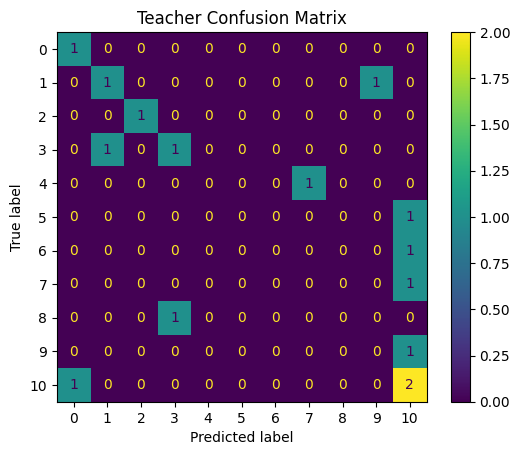

In [ ]:
vec_name, vec, model_name, model = best_teacher
print("BEST Teacher model:", vec_name, model_name)

# Refit on train+val
X_trainval = np.concatenate([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

Xtrv = vec.fit_transform(X_trainval)
Xte = vec.transform(X_test)

model.fit(Xtrv, y_trainval)
preds = model.predict(Xte)

print("Teacher TEST accuracy:", accuracy_score(y_test, preds))
print("Teacher TEST f1 weighted:", f1_score(y_test, preds, average="weighted"))
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Teacher Confusion Matrix")
plt.show()


#Subject Prediction

In [ ]:
X_original = df["Text_clean"].values
y_subject_original = df[SUBJECT_COL].values

# Create a temporary DataFrame for grouping rare classes
df_temp = pd.DataFrame({
    "Text_clean": X_original,
    SUBJECT_COL: y_subject_original
})

# Group rare subject classes with a min_count of 3 for robust stratified splitting
df_grouped = group_rare_classes(df_temp, SUBJECT_COL, min_count=3, other_name="OtherSubject")

X = df_grouped["Text_clean"].values
y = df_grouped[SUBJECT_COL].values

# Now perform the stratified train/val/test split with the grouped labels
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

majority = pd.Series(y_test).value_counts().idxmax()
baseline_acc = (y_test == majority).mean()
print("Subject baseline accuracy:", baseline_acc)

results_subj, best_subj = run_experiments(X_train, y_train, X_val, y_val)
results_subj.head(10)

Subject baseline accuracy: 0.26666666666666666


,Vectorizer,Model,Val_Acc,Val_F1_weighted,Val_F1_macro
0,BOW_uni,LogReg,0.642857,0.588435,0.420068
2,BOW_bi,LogReg,0.642857,0.576531,0.396259
3,BOW_bi,RF,0.642857,0.534694,0.318367
4,TFIDF_uni,LogReg,0.571429,0.500000,0.392857
6,TFIDF_bi,LogReg,0.500000,0.437291,0.359555
1,BOW_uni,RF,0.500000,0.403571,0.240476
5,TFIDF_uni,RF,0.428571,0.300000,0.171429
7,TFIDF_bi,RF,0.357143,0.255952,0.154762


#Interpretability

In [ ]:
def show_top_words(vec, model, top_n=12):
    if not hasattr(model, "coef_"):
        print("This model does not support coefficient-based interpretability.")
        return

    feature_names = vec.get_feature_names_out()
    classes = model.classes_

    for i, cls in enumerate(classes):
        top_idx = np.argsort(model.coef_[i])[::-1][:top_n]
        top_words = [feature_names[j] for j in top_idx]
        print(f"\nClass: {cls}")
        print("Top words:", top_words)

# Teacher
if best_teacher[2] == "LogReg":
    show_top_words(best_teacher[1], best_teacher[3], top_n=12)

# Subject
if best_subj[2] == "LogReg":
    show_top_words(best_subj[1], best_subj[3], top_n=12)



Class: Digital Narrative
Top words: ['maes', 'game', 'character', 'player', 'players', 'characters', 'narrative', 'games', 'you', 'dialogue', 'experience', 'night']

Class: English 10: American Literary Movements
Top words: ['his', 'money', 'to', 'and', 'government', 'equiano', 'society', 'fitzgerald', 'nonconformity', 'neo', 'he', 'daisy']

Class: English 1: World Literature
Top words: ['he', 'and', 'her', 'manipulated', 'easily', 'annie', 'by', 'macbeth', 'lady', 'when', 'siddhartha', 'siddartha']

Class: OtherSubject
Top words: ['would', 'deism', 'their', 'in', 'god', 'was', 'people', 'have', 'for', 'enlightenment', 'walter', 'while']

Class: Research Into Anglophone Literature
Top words: ['the', 'chaucer', 'disability', 'john', 'mona', 'smile', 'lisa', 'nicholas', 'painting', 'field', 'women', 'mad']

Class: Research into Anglophone Literature
Top words: ['of', 'selfreliance', 'his', 'croesus', 'as', 'neo', 'poem', 'the', 'bluebeard', 'by', 'gold', 'byzantium']

Class: Science Fic

#Summary

The best-performing model for the teacher prediction task was a Bag-of-Words unigram model using Logistic Regression. This model achieved a test accuracy of 0.67, which is higher than the majority-class baseline and shows that the model learned meaningful patterns from the essay text. However, the weighted F1-score of 0.33 and macro F1-score of 0.28 indicate uneven performance across different teachers. The prediction results show that teachers with more consistent or distinctive essay content were easier to identify. For example, Dr. Ermer was predicted perfectly, while Dr. Bufkin, Dr. Chuang, and Dr. Margini achieved moderate precision and recall. In contrast, several teachers with only one test example were not predicted correctly, resulting in zero precision and recall for those classes. The grouped “OtherTeacher” category achieved the highest recall, which suggests that having more examples per class significantly improves prediction performance.
For the subject prediction task, the best-performing model was also a Bag-of-Words model with Logistic Regression, achieving a validation accuracy of approximately 0.64 compared to a baseline accuracy of about 0.27. This large improvement over baseline indicates that the model was highly effective at identifying subject-related patterns in the essays. Subject prediction performed better than teacher prediction because subjects tend to have more distinctive, topic-specific vocabulary, making them easier to separate using word frequency features. Across all experiments, Logistic Regression consistently outperformed Random Forest models, and Bag-of-Words features performed slightly better than TF-IDF, suggesting that raw word frequency captured the most useful information for this dataset.
Overall, the best prediction results show that essay content plays a larger role than writing style in classification performance. Subject prediction benefited from clearer topical signals, while teacher prediction was limited by overlapping vocabulary, small class sizes, and class imbalance. Despite these limitations, both tasks performed better than random guessing and majority-class baselines, demonstrating that the NLP pipeline successfully extracted meaningful information from the essay text.